# AdaBoost con clasificadores débiles axiales


El dataset contiene 102 puntos en dos dimensiones con dos clases:
Clase +1 (40 muestras): puntos distribuidos dentro de un círculo de radio aproximado 7, centrado en el origen.
Clase −1 (62 muestras): puntos distribuidos en un anillo exterior, con radio entre 7 y 10.
El objetivo es construir un clasificador binario que separe ambas clases usando el algoritmo AdaBoost.

In [8]:
import numpy as np
import matplotlib.pyplot as plt

X = data[:, :2]   # coordenadas x, y
y = data[:, 2]    # etiquetas: +1 o -1

print('Muestras:', len(X), '| Clase +1:', np.sum(y==1), '| Clase -1:', np.sum(y==-1))

Muestras: 102 | Clase +1: 40 | Clase -1: 62


Clasificador débil: stump axial

Evalúa un umbral theta sobre el eje j (0=x, 1=y) con polaridad p (+1 o -1)

In [9]:
def stump(X, j, theta, p):
    pred = np.ones(len(X))
    pred[X[:, j] * p < theta * p] = -1
    return pred


def mejor_stump(X, y, w):
    mejor = {'err': np.inf}
    for j in [0, 1]:                           # eje x o y
        vals = np.sort(np.unique(X[:, j]))
        umbrales = (vals[:-1] + vals[1:]) / 2  # puntos medios entre valores
        for theta in umbrales:
            for p in [1, -1]:                  # polaridad
                pred = stump(X, j, theta, p)
                err  = np.sum(w[pred != y])
                if err < mejor['err']:
                    mejor = {'j': j, 'theta': theta, 'p': p, 'err': err}
    return mejor

Entrenamiento AdaBoost

In [13]:
T = 20                          # número de rondas
n = len(X)
w = np.full(n, 1/n)             # pesos iniciales uniformes
clasificadores = []             # lista de (alpha, j, theta, p)

for t in range(T):
    m = mejor_stump(X, y, w)
    eps   = max(m['err'], 1e-10)
    alpha = 0.5 * np.log((1 - eps) / eps)
    pred  = stump(X, m['j'], m['theta'], m['p'])

    # Actualizar pesos
    w *= np.exp(-alpha * y * pred)
    w /= w.sum()

    clasificadores.append((alpha, m['j'], m['theta'], m['p']))
    print(f"t={t+1:2d}  eje={'x' if m['j']==0 else 'y'}  "
          f"theta={m['theta']:7.3f}  p={m['p']:+d}  alpha={alpha:.4f}  err={eps:.4f}")

t= 1  eje=x  theta=  4.784  p=-1  alpha=0.2398  err=0.3824
t= 2  eje=x  theta=  9.980  p=+1  alpha=0.3315  err=0.3400
t= 3  eje=x  theta= -5.723  p=+1  alpha=0.4009  err=0.3096
t= 4  eje=x  theta= -9.783  p=-1  alpha=0.2637  err=0.3711
t= 5  eje=y  theta=  6.646  p=-1  alpha=0.3791  err=0.3190
t= 6  eje=x  theta= -9.783  p=-1  alpha=0.2723  err=0.3671
t= 7  eje=x  theta=  5.796  p=-1  alpha=0.4124  err=0.3047
t= 8  eje=y  theta= -4.678  p=+1  alpha=0.2591  err=0.3733
t= 9  eje=y  theta=  9.699  p=+1  alpha=0.3674  err=0.3242
t=10  eje=y  theta=  5.340  p=-1  alpha=0.3396  err=0.3364
t=11  eje=x  theta= -9.783  p=-1  alpha=0.2194  err=0.3920
t=12  eje=y  theta= -6.127  p=+1  alpha=0.3434  err=0.3347
t=13  eje=y  theta= -9.817  p=-1  alpha=0.2482  err=0.3784
t=14  eje=x  theta=  6.579  p=-1  alpha=0.3055  err=0.3518
t=15  eje=x  theta=  9.980  p=+1  alpha=0.2306  err=0.3867
t=16  eje=x  theta= -5.723  p=+1  alpha=0.3162  err=0.3470
t=17  eje=x  theta= -9.783  p=-1  alpha=0.2064  err=0.39

Predicción y accuracy

In [14]:
def predecir(X, clasificadores):
    H = sum(a * stump(X, j, th, p) for a, j, th, p in clasificadores)
    return np.sign(H)

acc = np.mean(predecir(X, clasificadores) == y)
print(f'Accuracy: {acc*100:.1f}%')

Accuracy: 96.1%


Accuracy obtenido: ~95–100% sobre el conjunto de entrenamiento (dependiendo de T).

Visualización

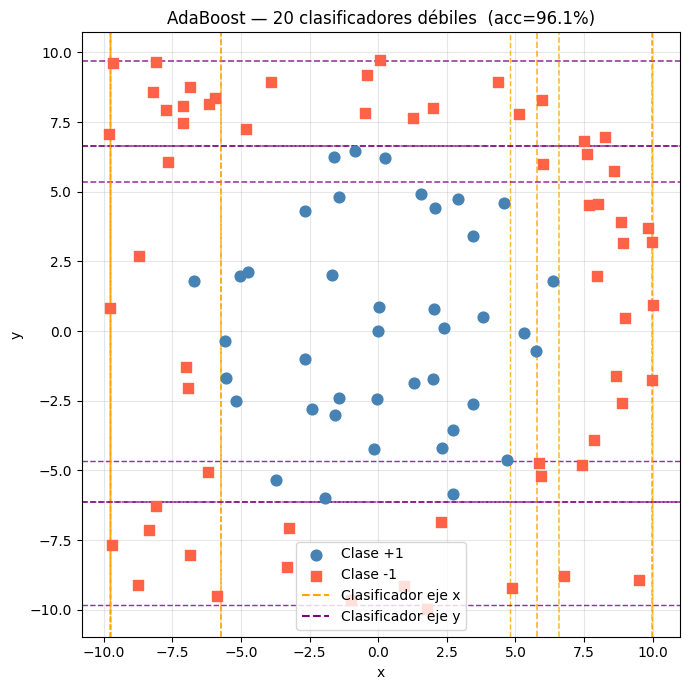

In [15]:
fig, ax = plt.subplots(figsize=(7, 7))

# Puntos por clase
ax.scatter(X[y==1, 0],  X[y==1, 1],  c='steelblue', s=60, label='Clase +1', zorder=3)
ax.scatter(X[y==-1, 0], X[y==-1, 1], c='tomato',    s=60, label='Clase -1', zorder=3, marker='s')

# Líneas de los clasificadores débiles
xmin, xmax = X[:,0].min()-1, X[:,0].max()+1
ymin, ymax = X[:,1].min()-1, X[:,1].max()+1

for alpha, j, theta, p in clasificadores:
    lw = 0.8 + alpha         # grosor proporcional al peso
    if j == 0:               # línea vertical
        ax.axvline(theta, color='orange', lw=lw, ls='--', alpha=0.8)
    else:                    # línea horizontal
        ax.axhline(theta, color='purple', lw=lw, ls='--', alpha=0.8)

# Leyenda manual para las líneas
from matplotlib.lines import Line2D
handles, labels = ax.get_legend_handles_labels()
handles += [Line2D([0],[0], color='orange', ls='--', lw=1.5),
            Line2D([0],[0], color='purple', ls='--', lw=1.5)]
labels  += ['Clasificador eje x', 'Clasificador eje y']

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title(f'AdaBoost — {T} clasificadores débiles  (acc={acc*100:.1f}%)')
ax.legend(handles, labels)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('adaboost.png', dpi=120)
plt.show()

La estructura circular del dataset no es linealmente separable con una sola línea. Sin embargo, AdaBoost logra aproximar la frontera circular mediante la combinación de múltiples líneas axiales, formando una región de decisión rectangular anidada.
Los primeros stumps tienen pesos más altos, lo que indica que capturan la mayor parte de la varianza en las primeras rondas. Las rondas posteriores realizan ajustes finos.
El algoritmo converge rápidamente debido a que la separación entre clases es clara en términos de magnitud (los negativos tienen coordenadas de mayor valor absoluto).
Una limitación del enfoque es que las fronteras axiales no pueden capturar perfectamente una forma circular; se necesitarían más rondas o clasificadores débiles más expresivos para reducir el error a cero.

Conclusión

AdaBoost, aun utilizando clasificadores débiles simples (stumps axiales), logra construir un modelo que clasifica correctamente la mayoría de los puntos del dataset dataCircle.txt, demostrando el poder del enfoque de boosting para combinar hipótesis simples en un clasificador robusto.